# Chapter 7 Vision Transformers

After this chapter you should be able to:

1. **Explain the motivation for Vision Transformers (ViTs).**  
   Describe why ViTs became important not only for image classification, but also as a building block for modern generative models and vision-language models.

2. **Describe the transition from language tokens to image patches.**  
   Explain how an image can be split into fixed-size patches, embedded as vectors, and processed as a token sequence by a transformer.

3. **Write down the core mathematics of a ViT.**  
   Interpret patch embedding, positional embeddings, self-attention, multilayer perceptrons, residual connections, and the final classification head using standard tensor shapes and equations.

4. **Distinguish ViTs from token-based language transformers.**  
   Identify what is reused from NLP transformers and what must be added or changed for vision, such as patch embedding, 2D positional structure, and class-token usage.

5. **Explain the task dimension of a ViT encoder.**  
   Compare using the same encoder for **classification** versus **general image encoding**, and explain why a class token is often added for classification.

6. **Understand the historical development of Vision Transformers.**  
   Recognize a few influential milestones such as the original Transformer, DETR, ViT, DeiT, Swin, MAE, CLIP, and SigLIP.

7. **Implement a ViT-style classifier for CIFAR-10.**  
   Follow the PyTorch implementation of patch embedding, transformer blocks, and a classification head for a small image dataset.

8. **Train and evaluate a ViT-based image classifier.**  
   Run the CIFAR-10 pipeline, interpret logits and predictions, and understand the role of the loss function and evaluation metrics.

9. **Connect ViTs to the next topic: Vision-Language Models.**  
   See why the same image encoder ideas naturally extend to CLIP/SigLIP-style image encoders and then to larger multimodal systems.


## License

**Text, figures, and explanations:**  
© 2026 Imran Zualkernan. Licensed under **CC BY 4.0**.

**Code cells:**  
© 2026 Imran Zualkernan. Licensed under the **MIT License**.

You are free to reuse, modify, and redistribute with attribution.

## Why Vision Transformers Matter for Modern Generative Models

Vision Transformers (ViTs) began as a discriminative architecture for image recognition: the central idea is to split an image into fixed-size patches, linearly embed those patches, add positional information, and then process the resulting sequence with a standard Transformer encoder. In other words, a ViT reframes an image as a sequence of visual tokens. This is one of the key reasons ViTs became so influential: they create a natural bridge between **language-style token processing** and **image-based learning**.

### Token-based View for Vision
That token-based view turned out to be extremely important for generative modeling. Modern generative models need a representation that is easy to **condition**, **scale**, and **mix across modalities**. Once an image is represented as patches or latent visual tokens, the model can apply self-attention over all tokens, inject time or noise-step information as additional embeddings, and combine image tokens with text tokens or other conditioning signals in a unified Transformer-style computation. This is why transformer ideas moved from image classification into **image generation**, **text-to-image generation**, and **multimodal generation**.

### Exploiting Global Context
A second reason is **global context**. In generative modeling, the system must coordinate structure across the whole image: object layout, symmetry, repeated patterns, long-range dependencies, and consistency between distant regions. Self-attention gives every token a direct path to every other token, which makes it well suited to modeling global structure. This benefit appears clearly in transformer-based image generators such as **MaskGIT**, and in diffusion-transformer architectures such as **U-ViT** and **DiT**, where image patches or latent patches are processed by Transformer blocks instead of only convolutional blocks.

### Scaling
A third reason is **scaling**. Diffusion Transformers such as **DiT** showed that replacing the usual diffusion U-Net with a transformer operating on latent patches is not only possible, but highly effective at scale. This made transformers attractive not just because they are elegant, but because they scale in a predictable and empirically strong way for generation. Later architectures such as **SiT** further showed that a similar transformer backbone can also support broader flow- and interpolant-based generative modeling.

### Multimodal Compatibility
A fourth reason is **multimodal compatibility**. In text-to-image systems, the generator must connect visual structure with language. Transformer-based vision backbones fit this especially well because both sides can be expressed in token form. This is explicit in architectures such as **U-ViT**, which treats noisy image patches, time, and conditions as tokens in one transformer-style framework, and in modern multimodal diffusion systems that jointly process image and language representations.

For that reason, it is helpful to think of ViTs as more than “classifiers without convolutions.” They introduced a representation and computation style that modern generative models could reuse:

1. turn images into tokens  
2. model token interactions with attention  
3. add conditioning information as tokens or embeddings  
4. scale the same backbone across tasks  

In this chapter we focus on **classification** using CIFAR-10, but we study Vision Transformers in this form because the same basic encoder idea extends naturally to **image encoding**, **contrastive vision-language learning** (such as CLIP and SigLIP), and to **modern generative backbones** used in image synthesis and multimodal systems.

### Examples of Recent Vision Transformers

- **MaskGIT**: image synthesis by predicting masked visual tokens with a bidirectional transformer.
- **U-ViT**: a ViT-style diffusion backbone that treats noisy image patches, time, and conditions as tokens.
- **DiT**: a diffusion transformer that operates over latent patches and scales strongly with model size and compute.
- **SiT**: a transformer-based generative architecture that extends the same backbone style beyond standard diffusion.
- **CLIP / SigLIP**: contrastive multimodal systems where the image side is a ViT-style encoder, creating a direct bridge from visual encoding to vision-language models.

### Summary

We study Vision Transformers because they provide a **token-based visual representation** that now serves as a foundation for modern image encoders, vision-language models, and many state-of-the-art generative architectures.

## A short history of Vision Transformers

The modern Vision Transformer did **not** appear in isolation. It emerged from a sequence of ideas that gradually moved the transformer from **language sequences** to **vision representations**.

### Historical Overview

1. **Transformer in NLP (2017).**  
   The original transformer showed that sequence modeling can be built entirely around self-attention, without recurrence or convolution. This is the conceptual starting point for ViTs.

2. **Transformer ideas enter vision tasks (2020).**  
   DETR showed that transformers can operate on visual features for **object detection**, reframing detection as a direct set-prediction problem. This was an important signal that transformer-style reasoning could be useful beyond language.

3. **Pure patch-based ViT for image classification (2021).**  
   The ViT paper showed that if an image is split into patches and each patch is treated as a token, then a nearly standard transformer encoder can work directly on images for **classification**.

4. **Data-efficient ViTs (2021).**  
   DeiT showed that ViTs can be trained more efficiently on ImageNet-scale data and introduced a **distillation token**, which is task-specific supervision injected into the token sequence.

5. **Hierarchical and dense-prediction ViTs (2021).**  
   Swin Transformer addressed the fact that many vision tasks need multi-scale structure and local windows, which become especially important for detection and segmentation.

6. **Self-supervised ViTs (2022).**  
   MAE showed that ViTs are also strong **encoders** for self-supervised representation learning by masking image patches and reconstructing them.

7. **Vision encoders for multimodal learning (2021 onward).**  
   CLIP and later SigLIP used ViT-like image encoders as the visual side of vision-language systems, which is one reason ViTs are such a natural bridge to modern VLMs.

### References

1. **Vaswani, A., Shazeer, N., Parmar, N., Uszkoreit, J., Jones, L., Gomez, A. N., Kaiser, L., & Polosukhin, I. (2017).**  
   *Attention Is All You Need.*  
   In *Advances in Neural Information Processing Systems 30 (NeurIPS 2017).*  
   Official link: https://papers.nips.cc/paper/7181-attention-is-all-you-need  
   PDF: https://papers.nips.cc/paper_files/paper/2017/file/3f5ee243547dee91fbd053c1c4a845aa-Paper.pdf

2. **Carion, N., Massa, F., Synnaeve, G., Usunier, N., Kirillov, A., & Zagoruyko, S. (2020).**  
   *End-to-End Object Detection with Transformers.*  
   In *Proceedings of the European Conference on Computer Vision (ECCV 2020).*  
   Official link: https://www.ecva.net/papers/eccv_2020/papers_ECCV/html/832_ECCV_2020_paper.php  
   PDF: https://www.ecva.net/papers/eccv_2020/papers_ECCV/papers/123460205.pdf

3. **Dosovitskiy, A., Beyer, L., Kolesnikov, A., Weissenborn, D., Zhai, X., Unterthiner, T., Dehghani, M., Minderer, M., Heigold, G., Gelly, S., Uszkoreit, J., & Houlsby, N. (2021).**  
   *An Image is Worth 16x16 Words: Transformers for Image Recognition at Scale.*  
   In *International Conference on Learning Representations (ICLR 2021).*  
   Official link: https://openreview.net/forum?id=YicbFdNTTy  
   arXiv: https://arxiv.org/abs/2010.11929

4. **Touvron, H., Cord, M., Douze, M., Massa, F., Sablayrolles, A., & Jégou, H. (2021).**  
   *Training data-efficient image transformers & distillation through attention.*  
   In *Proceedings of the 38th International Conference on Machine Learning*, *PMLR 139*, pp. 10347-10357.  
   Official link: https://proceedings.mlr.press/v139/touvron21a.html  
   PDF: https://proceedings.mlr.press/v139/touvron21a/touvron21a.pdf

5. **Liu, Z., Lin, Y., Cao, Y., Hu, H., Wei, Y., Zhang, Z., Lin, S., & Guo, B. (2021).**  
   *Swin Transformer: Hierarchical Vision Transformer using Shifted Windows.*  
   In *Proceedings of the IEEE/CVF International Conference on Computer Vision (ICCV 2021).*  
   Official link: https://openaccess.thecvf.com/content/ICCV2021/html/Liu_Swin_Transformer_Hierarchical_Vision_Transformer_Using_Shifted_Windows_ICCV_2021_paper.html  
   PDF: https://openaccess.thecvf.com/content/ICCV2021/papers/Liu_Swin_Transformer_Hierarchical_Vision_Transformer_Using_Shifted_Windows_ICCV_2021_paper.pdf

6. **He, K., Chen, X., Xie, S., Li, Y., Dollár, P., & Girshick, R. (2022).**  
   *Masked Autoencoders Are Scalable Vision Learners.*  
   In *Proceedings of the IEEE/CVF Conference on Computer Vision and Pattern Recognition (CVPR 2022).*  
   Official link: https://openaccess.thecvf.com/content/CVPR2022/html/He_Masked_Autoencoders_Are_Scalable_Vision_Learners_CVPR_2022_paper.html  
   PDF: https://openaccess.thecvf.com/content/CVPR2022/papers/He_Masked_Autoencoders_Are_Scalable_Vision_Learners_CVPR_2022_paper.pdf

7. **Radford, A., Kim, J. W., Hallacy, C., Ramesh, A., Goh, G., Agarwal, S., Sastry, G., Askell, A., Mishkin, P., Clark, J., Krueger, G., & Sutskever, I. (2021).**  
   *Learning Transferable Visual Models From Natural Language Supervision.*  
   In *Proceedings of the 38th International Conference on Machine Learning*, *PMLR 139*, pp. 8748-8763.  
   Official link: https://proceedings.mlr.press/v139/radford21a.html  
   PDF: https://proceedings.mlr.press/v139/radford21a/radford21a.pdf

8. **Zhai, X., Mustafa, B., Kolesnikov, A., & Beyer, L. (2023).**  
   *Sigmoid Loss for Language Image Pre-Training.*  
   In *Proceedings of the IEEE/CVF International Conference on Computer Vision (ICCV 2023).*  
   Official link: https://openaccess.thecvf.com/content/ICCV2023/html/Zhai_Sigmoid_Loss_for_Language_Image_Pre-Training_ICCV_2023_paper.html  
   PDF: https://openaccess.thecvf.com/content/ICCV2023/papers/Zhai_Sigmoid_Loss_for_Language_Image_Pre-Training_ICCV_2023_paper.pdf

### Why History is Important

This timeline helps separate three related but different roles for transformers in vision:

- **Classification backbones**: ViT, DeiT
- **Dense-prediction backbones**: Swin, DETR-style systems
- **Representation encoders** for self-supervised or multimodal learning: MAE, CLIP, SigLIP

This chapter is focussed on the first role: **classification** with an example from CIFAR-10. But the same encoder family can also be reused for **encoding** in CLIP/SigLIP-style vision-language models.

## What is a Vision Transfomer?

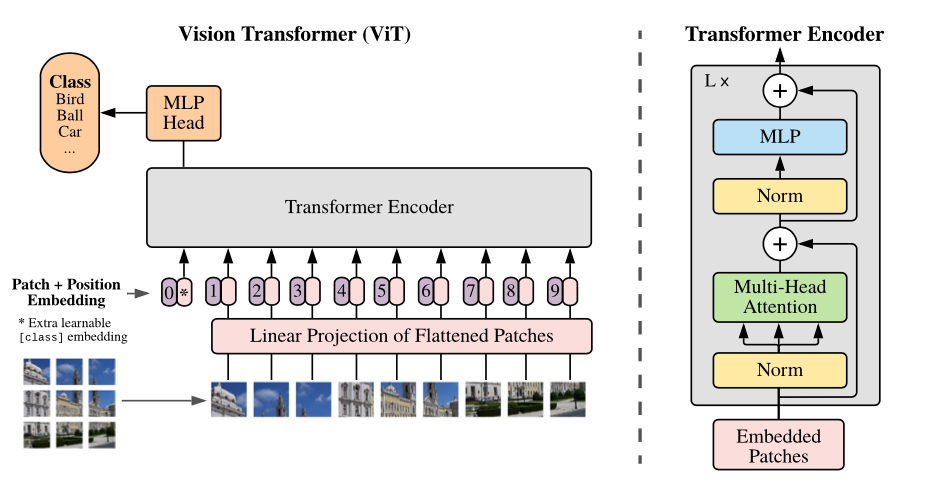


https://viso.ai/deep-learning/vision-transformer-vit/

This diagram shows how a **Vision Transformer (ViT)** converts an image into a prediction. The key ideas in the **architecture** are described below. 

### 1. Image split into patches
The input image is divided into small fixed-size patches, for example $16 \times 16$.  
If the image has size $H \times W$ and the patch size is $P \times P$, then the number of patches is

$$
N = \frac{H}{P}\frac{W}{P}
$$

Each patch plays a role similar to a **token** in language models.

### 2. Linear projection of flattened patches
Each image patch is flattened into a vector and passed through a learned linear layer to produce a patch embedding. So each patch becomes a vector in $\mathbb{R}^D$, where $D$ is the embedding dimension.

### 3. Patch + position embedding
Since transformers do not automatically know where a token came from, we add a **positional embedding** to each patch embedding so the model knows the spatial location of each patch in the image.

### 4. Class token
A special learnable **class token** is added to the front of the patch sequence. **Its role is to collect information from all patches through self-attention, and its final representation is used for classification.**

### 5. Transformer encoder
The sequence of tokens is passed through several stacked transformer encoder blocks.

Each encoder block contains:

- **Layer Normalization (Norm):** stabilizes training
- **Multi-Head Attention:** lets each patch attend to all other patches
- **Residual connection (+):** adds the block input back to the output
- **MLP:** a feedforward network that further transforms each token
- **Another residual connection (+):** helps preserve and refine information across layers

This whole encoder block is repeated $L$ times.

### 6. MLP head
After the final encoder layer, the output corresponding to the **class token** only is sent to a small **MLP head** (classifier).

### 7. Class prediction
The MLP head produces the final output logits, which correspond to classes such as:

- Bird
- Ball
- Car
- etc.

### Main intuition
A ViT treats an image as a **sequence of patch tokens**, just as a language transformer treats a sentence as a **sequence of word tokens**.  
The main difference is that for images we must first:
1. split the image into patches,
2. embed the patches,
3. add positional information,
4. and often add a class token for classification.

## Task dimension: classification vs. encoding, and why the class token is added

A Vision Transformer can be used for more than one kind of task. The most important distinction is between:

1. **Classification**
2. **General-purpose encoding**

These use almost the same encoder, but the **output head** and sometimes the **pooling choice** differ.

### Classification

In image classification, the goal is to map an image to one label among $K$ classes:

$$
f_{\theta}(I) \in \mathbb{R}^{K}.
$$

A ViT first produces a sequence of hidden vectors

$$
X^{(L)} = [x_{\mathrm{cls}}^{(L)}; x_1^{(L)}; \dots; x_N^{(L)}] \in \mathbb{R}^{(N+1) \times D}.
$$

If we use a class token, the classifier usually reads only the final class-token state:

$$
\text{logits} = W_{\mathrm{cls}} x_{\mathrm{cls}}^{(L)} + b,
$$

where

$$
W_{\mathrm{cls}} \in \mathbb{R}^{K \times D}, \qquad b \in \mathbb{R}^{K}.
$$

This is the setup used in the original ViT paper for image classification.

### General-purpose encoding

In representation learning or multimodal learning, we usually want one **image embedding** rather than class logits.  
So instead of producing $K$ class scores, the encoder produces a vector

$$
h(I) \in \mathbb{R}^{D}.
$$

That vector can then be used for:

- retrieval
- clustering
- transfer learning
- contrastive learning
- image-text alignment in CLIP or SigLIP

The final image embedding can come from:

- the **class token**
- the **mean of all patch tokens**
- a learned **attention pooling** mechanism

So the encoder is similar, but the **task head changes**.

### Why add a class token?

> The class token is a **learned vector**. Unlike other **tokens** that come from the image **patches**, the class token is a **learned vector** that is updated through **back-propagation**. It is intialized to a **random** value, is shared by all other **tokens** and gets updated based on the **loss function**. 

$$
x_{\mathrm{cls}} \in \mathbb{R}^{D}
$$

that is prepended to the patch-token sequence:

$$
X_0 = [x_{\mathrm{cls}}; z_1; z_2; \dots; z_N].
$$

During self-attention, this token can attend to all patch tokens and gather information from the whole image. This is possible because unlike **text** in **images** we do **not** have a **causal mask** to ignore **future values** and hence **attention** is **bi-directional**.  Without this, the class token will **not** work. The class token is **special** because unlike other tokens that get updated from the **input iamge**, the class token accumulates **values** from other tokens. 

After several transformer layers, the final class-token state can be interpreted as a **global summary** of the image.

So the class token is useful because it gives the model a designated location for storing image-level information that can be fed directly to a classifier.

### Backpropagation through the CLS token

A simple way to think about the forward computation is

$$
c \;\rightarrow\; X^{(0)} \;\rightarrow\; X^{(1)} \;\rightarrow\; \cdots \;\rightarrow\; h_{\mathrm{cls}} \;\rightarrow\; z \;\rightarrow\; \mathcal{L}
$$

where:

- $c$ is the initial learned CLS token
- $X^{(0)}$ is the input token sequence to the transformer
- $X^{(1)}, X^{(2)}, \dots$ are the intermediate transformer layer outputs
- $h_{\mathrm{cls}}$ is the final CLS representation
- $z$ is the classifier output (logits)
- $\mathcal{L}$ is the loss

Backpropagation then flows in the reverse direction:

$$
\mathcal{L} \;\rightarrow\; z \;\rightarrow\; h_{\mathrm{cls}} \;\rightarrow\; \cdots \;\rightarrow\; X^{(0)} \;\rightarrow\; c
$$

This means the loss produces a gradient with respect to the initial CLS token:

$$
\frac{\partial \mathcal{L}}{\partial c}
$$

and that gradient is used to update the CLS token during training.

Using gradient descent, the update equation is

$$
c \leftarrow c - \eta \frac{\partial \mathcal{L}}{\partial c}
$$

where $\eta$ is the learning rate.

So the key idea is:

> the CLS token starts as a learned parameter, participates in the full forward pass, and is updated by backpropagation just like any other trainable weight in the model.

### Is the class token mandatory?

No. Many vision models instead use **mean pooling**:

$$
h(I) = \frac{1}{N} \sum_{i=1}^{N} x_i^{(L)}.
$$

This often works well, especially for smaller datasets or simple demonstrations.

In practice:

- **class token** is historically associated with ViT-style classification
- **mean pooling** is often simpler and sometimes more stable
- **contrastive or multimodal encoders** may use either, depending on design choices

### What changes between the two task types?

For the same patch-and-transformer encoder:

- **classification**
  - output is class logits
  - a linear classification head is added
  - the loss is usually cross-entropy

- **encoding**
  - output is a feature vector
  - the head may be identity, projection, or normalization
  - the loss may be contrastive, sigmoid, or self-supervised reconstruction/alignment loss

This is exactly why ViTs are such a strong bridge to vision-language models: the **core visual encoder stays similar**, while the downstream head and objective change.

## Positional encodings in Vision Transformers

Transformers are permutation-invariant, so a Vision Transformer (ViT) needs positional information to know where each patch came from. In the original ViT, this was handled with **learned absolute positional embeddings** added to the patch tokens before the transformer blocks.

If the patch-token matrix is

$$
X = [x_1,\dots,x_N], \qquad x_i \in \mathbb{R}^D,
$$

then the simplest positional encoding is

$$
x_i' = x_i + p_i,
$$

where $p_i \in \mathbb{R}^D$ is the positional embedding for token $i$. 

Here:

- $N$ = number of patch tokens
- $D$ = token embedding dimension

In vision, each token usually comes from a 2D patch location on an image grid, so a central design question is whether position should be encoded as a **1D sequence index** after flattening, or using the **2D image structure** explicitly. Various types of positional encodings can be considered. 

### Absolute positional encodings

#### Fixed sinusoidal absolute encoding

This is the classic transformer approach from NLP. Each position is mapped to a deterministic sine/cosine vector, as introduced in *Attention Is All You Need*. It is parameter-free and can generalize more naturally to unseen sequence lengths than a fixed learned table, but in its standard form it is fundamentally **1D**.

#### Learned absolute encoding

This is the standard ViT choice. A learnable positional table

$$
P \in \mathbb{R}^{N \times D}
$$

is added to the patch tokens:

$$
X' = X + P.
$$

This works very well for fixed-resolution classification. A drawback is that when the input resolution changes, the learned positional table usually has to be interpolated. So we **learn** through backpropagation, a vector representing **each** position. We treat each positions's vector as a **learnable parameter** which is updated based on the **backwards** pass. 

### 2D absolute positional encodings

Because image patches lie on a 2D grid, a natural alternative is to encode row and column positions separately. A common factorized form is

$$
p_{u,v} = p^{(x)}_u + p^{(y)}_v,
$$

so that the token at grid location $(u,v)$ becomes

$$
x_{u,v}' = x_{u,v} + p^{(x)}_u + p^{(y)}_v.
$$

This is often more natural than flattening the image into a 1D sequence because it preserves the fact that images have horizontal and vertical structure. **NaViT** explicitly revisits positional embeddings for arbitrary aspect ratios and resolutions, using factorized and fractional positional embeddings to better support native-resolution inputs.

### Relative positional encodings

Instead of telling the model where a patch is in absolute terms, relative positional encoding tells the model how two patches are positioned relative to each other. This is often a good fit for vision, where relations such as “above,” “left of,” and “near” matter directly.

A standard form is to add a bias term to the attention logits:

$$
\mathrm{Attention}(Q,K,V)
=
\mathrm{softmax}\!\left(\frac{QK^\top}{\sqrt{d}} + B\right)V,
$$

where $B_{ij}$ depends on the relative displacement between token $i$ and token $j$.

For images, this is often written as

$$
B_{ij} = b(\Delta x_{ij}, \Delta y_{ij}),
$$

so the attention score depends on 2D offset. Swin Transformer uses **relative position bias**, and its reported ablation gains were substantial: compared with no positional encoding, **Swin-T** improved by **+1.2 top-1** on ImageNet-1K, **+1.3 box AP / +1.1 mask AP** on COCO, and **+2.3 mIoU** on ADE20K; compared with absolute positional embedding, it improved by **+0.8 top-1**, **+1.5 box AP / +1.3 mask AP**, and **+2.9 mIoU**.

### Image-specific 2D relative encodings

A plain 1D relative encoding is inherited from language models and does not fully respect image geometry. That motivated image-specific designs such as **iRPE** in *Rethinking and Improving Relative Position Encoding for Vision Transformer*. The idea is to encode 2D spatial relations more explicitly, including direction and distance on the image grid rather than only sequence offset after flattening. That paper reports that, purely due to the new encoding, **DeiT** and **DETR** obtain up to **+1.5% top-1 accuracy** on ImageNet and **+1.3 mAP** on COCO without retuning extra hyperparameters.

### Conditional positional encodings

Instead of storing a fixed positional table, **conditional positional encoding (CPE)** generates the positional signal from the current token neighborhood itself. In CPVT, this is done with a **Position Encoding Generator (PEG)**, giving a form like

$$
X' = X + \mathrm{PEG}(X).
$$

This is attractive because the positional signal is **input-conditioned** instead of fixed. **CPVT** reports several concrete gains:

- **CPVT-Ti (0-1 PEG)** reaches **72.4%** top-1 on ImageNet vs **72.2%** for DeiT-tiny using learned positional embeddings, a gain of **+0.2**.
- **CPVT-Ti (0-5 PEG)** reaches **73.4%**, which the paper states is **+1.2** over DeiT-tiny.
- Adding PEG to **Swin-Tiny** boosts ImageNet top-1 from **81.10%** to **82.25%**, a gain of **+1.15**.
- For **PVT-tiny**, PEG improves ImageNet top-1 from **75.0%** to **77.3%** (**+2.3**), ADE20K mIoU from **35.7%** to **38.0%** (**+2.3**), and COCO mAP from **36.7** to **38.0** (**+1.3**).

### Rotary positional encodings (RoPE) for vision

**RoPE** applies position information by rotating queries and keys before attention. In vision, this can be extended to 2D patch coordinates. A schematic form is

$$
\tilde q_{u,v} = R_{u,v} q_{u,v}, \qquad
\tilde k_{u,v} = R_{u,v} k_{u,v},
$$

and the attention uses $\tilde q_{u,v}^\top \tilde k_{u',v'}$.

The recent paper *Rotary Position Embedding for Vision Transformer* shows especially strong gains for **resolution extrapolation**. For one reported ViT setting evaluated at **384 x 384**, top-1 accuracy improves from **84.2** with absolute positional embedding to **85.6** with RoPE-Mixed, a gain of **+1.4**. At **512 x 512**, the same table shows **82.2** with absolute positional embedding versus **84.7** with RoPE-Mixed, a gain of **+2.5**. The same paper also reports COCO detection gains for DINO-ViTDet: **ViT-B** improves from **49.4** box AP to **51.2** with RoPE-Mixed (**+1.8**), and **ViT-L** improves from **51.1** to **52.9** (**+1.8**).

### Does it make sense to use 2D positional embeddings?

Yes. In vision, tokens come from a 2D patch grid rather than a naturally 1D sequence, so 2D-aware positional encoding is conceptually well motivated. It preserves horizontal and vertical structure, makes relative spatial reasoning more explicit, and is usually a better inductive bias for image tasks than pretending the image is fundamentally 1D.

### How much difference does that make?

For **fixed-resolution image classification**, the difference is often **modest**. Vanilla ViT already showed that simple learned absolute positional embeddings can work very well when the training and test resolution are matched.

But for **detection, segmentation, localization, varying aspect ratios, and changing resolutions**, the positional design matters more. The numbers above make that concrete:

- **Swin** relative bias yields about **+0.8 to +1.2** top-1 on **ImageNet**, but much larger dense-task gains such as **+1.5 box AP**, **+1.3 mask AP**, and **+2.9 mIoU** over absolute positional encoding.
- **iRPE** reports up to **+1.5** ImageNet top-1 and **+1.3 mAP** on COCO.
- **CPVT-style PEG** gives anything from small gains like **+0.2** to larger gains like **+1.2** on DeiT-tiny, and even **+2.3** on PVT-tiny ImageNet top-1.
- **RoPE-ViT** gives especially strong gains when the inference resolution increases, such as **+1.4** at **384 x 384** and **+2.5** at **512 x 512** in the cited table.

So the more your task depends on spatial geometry or resolution transfer, the more sensible a 2D-aware positional encoding becomes.

### Practical rule of thumb for Positional Encoding

- For a simple fixed-resolution classifier, **learned absolute positional embeddings** are still a strong and simple baseline.
- For detection, segmentation, or strong spatial reasoning, **2D relative bias** or another 2D-aware method is usually the safer choice.
- For variable resolution, variable aspect ratio, or resolution extrapolation, **factorized 2D embeddings, conditional positional encodings, or 2D RoPE** are especially attractive.

### References for Positional Encodings 

1. **Ashish Vaswani, Noam Shazeer, Niki Parmar, Jakob Uszkoreit, Llion Jones, Aidan N. Gomez, Lukasz Kaiser, and Illia Polosukhin.** *Attention Is All You Need.* In *Advances in Neural Information Processing Systems 30 (NeurIPS 2017)*, pp. 5998-6008, 2017. Official proceedings page: https://papers.nips.cc/paper/7181-attention-is-all-you-need

2. **Alexey Dosovitskiy, Lucas Beyer, Alexander Kolesnikov, Dirk Weissenborn, Xiaohua Zhai, Thomas Unterthiner, Mostafa Dehghani, Matthias Minderer, Georg Heigold, Sylvain Gelly, Jakob Uszkoreit, and Neil Houlsby.** *An Image is Worth 16x16 Words: Transformers for Image Recognition at Scale.* In *International Conference on Learning Representations (ICLR)*, 2021. Official OpenReview page: https://openreview.net/forum?id=YicbFdNTTy

3. **Ze Liu, Yutong Lin, Yue Cao, Han Hu, Yixuan Wei, Zheng Zhang, Stephen Lin, and Baining Guo.** *Swin Transformer: Hierarchical Vision Transformer Using Shifted Windows.* In *Proceedings of the IEEE/CVF International Conference on Computer Vision (ICCV)*, pp. 10012-10022, 2021. Official open-access page: https://openaccess.thecvf.com/content/ICCV2021/html/Liu_Swin_Transformer_Hierarchical_Vision_Transformer_Using_Shifted_Windows_ICCV_2021_paper.html

4. **Kan Wu, Houwen Peng, Minghao Chen, Jianlong Fu, and Hongyang Chao.** *Rethinking and Improving Relative Position Encoding for Vision Transformer.* In *Proceedings of the IEEE/CVF International Conference on Computer Vision (ICCV)*, pp. 10033-10041, 2021. Official open-access page: https://openaccess.thecvf.com/content/ICCV2021/html/Wu_Rethinking_and_Improving_Relative_Position_Encoding_for_Vision_Transformer_ICCV_2021_paper.html

5. **Xiangxiang Chu, Zhi Tian, Bo Zhang, Xinlong Wang, and Chunhua Shen.** *Conditional Positional Encodings for Vision Transformers.* arXiv:2102.10882, 2021; revised 2023 and accepted to ICLR 2023. Official arXiv page: https://arxiv.org/abs/2102.10882

6. **Byeongho Heo, Song Park, Dongyoon Han, and Sangdoo Yun.** *Rotary Position Embedding for Vision Transformer.* arXiv:2403.13298, 2024; accepted to ECCV 2024. Official arXiv page: https://arxiv.org/abs/2403.13298

7. **Mostafa Dehghani, Basil Mustafa, Josip Djolonga, Jonathan Heek, Matthias Minderer, Mathilde Caron, Andreas Steiner, Joan Puigcerver, Robert Geirhos, Ibrahim Alabdulmohsin, Avital Oliver, Piotr Padlewski, Alexey Gritsenko, Mario Lucic, and Neil Houlsby.** *Patch n' Pack: NaViT, a Vision Transformer for any Aspect Ratio and Resolution.* arXiv:2307.06304, 2023. Official arXiv page: https://arxiv.org/abs/2307.06304

## Building a Vision Transformer for CIFAR10

We will build a vision transformer for CIFAR10 to demonstrate the various architectural elements of a Vision Transformer. 

In [2]:
!pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 4.8 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 11.0 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 12.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [matplotlib]5 [matplotlib]


In [3]:
import math
import random

import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as T
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

In [4]:
def set_seed(seed: int = 42):
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda


## CIFAR-19 Data

We download CIFAR-10 and create standard training and test loaders.

For training, we use light augmentation:

- random crop with padding
- random horizontal flip
- normalization

For evaluation, we only normalize.

In [ ]:
#!pip install torch torchvision matplotlib
from torchvision import datasets, transforms

# This mean and std are commonly used for normalizing CIFAR-10 images

mean = (0.4914, 0.4822, 0.4465)
std  = (0.2023, 0.1994, 0.2010)

train_tfms = T.Compose([
    T.RandomCrop(32, padding=4),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize(mean, std),
])

test_tfms = T.Compose([
    T.ToTensor(),
    T.Normalize(mean, std),
])

train_ds = torchvision.datasets.CIFAR10(
    root="./data_cifar10",
    train=True,
    download=True,
    transform=train_tfms,
)

test_ds = torchvision.datasets.CIFAR10(
    root="./data_cifar10",
    train=False,
    download=True,
    transform=test_tfms,
)

classes = train_ds.classes
print(classes)

100.0%


['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [ ]:
batch_size = 128

train_loader = DataLoader(
    train_ds,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0, # keep it 0 for first run, you can increase it later for faster data loading
    pin_memory=torch.cuda.is_available(),
)

test_loader = DataLoader(
    test_ds,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0, # keep it 0 for first run, you can increase it later for faster data loading
    pin_memory=torch.cuda.is_available(),
)

print("train batches:", len(train_loader))
print("test batches:", len(test_loader))

train batches: 391
test batches: 79


## Visualize a few training images

The tensors are normalized, so for display we undo the normalization.

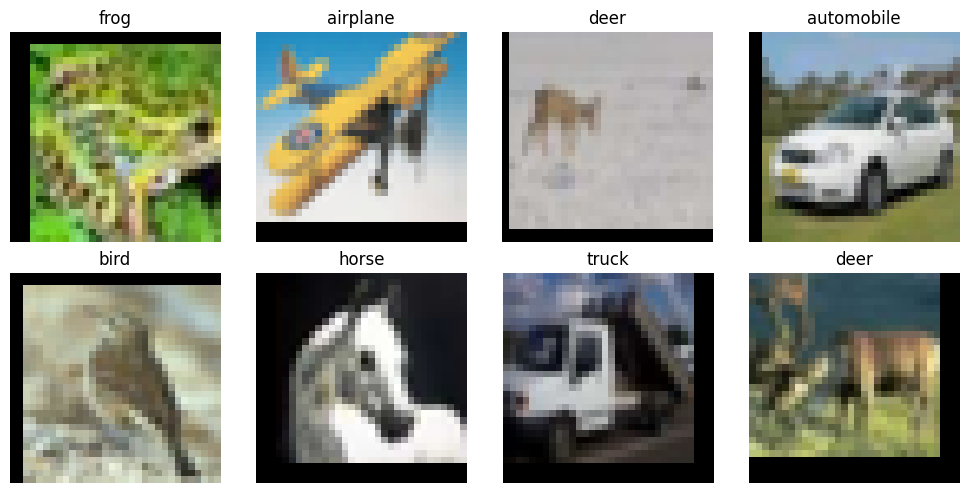

In [8]:
def denormalize(img):
    mean_t = torch.tensor(mean).view(3, 1, 1)
    std_t = torch.tensor(std).view(3, 1, 1)
    return (img * std_t + mean_t).clamp(0, 1)

images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for ax, img, label in zip(axes.flat, images[:8], labels[:8]):
    ax.imshow(denormalize(img).permute(1, 2, 0))
    ax.set_title(classes[label.item()])
    ax.axis("off")
plt.tight_layout()
plt.show()

## Patch embedding

The patch embedding uses a **clever trick** of applying a **convolutional layer** without an **activation function** to the original image in a manner so that the **output** of application of each **filter** represents one dimension of the **token** projection. So each **input patch** is run through all **convolutional filters** as the linear projections. Each **filter** produces one **scalar output** for each **patch**; applying all filters gives a dimension $D$ for the **token** embedding.  We apply **all filters** to each **patch** and hence the number of **filters** is kept the same as the **output dimension** required. Since **kernel size** and **stride** is the same as the **patch size**, the **convolutional layer** also automatically slices the image into non-overlapping **patches** at the same time. 

The patch embedding layer converts an input image of shape

$$
[B, C, H, W]
$$

into a sequence of patch tokens of shape

$$
[B, N, D]
$$

using the convolution

```python
nn.Conv2d(
    in_chans,
    embed_dim,
    kernel_size=patch_size,
    stride=patch_size,
    bias=True,
)
```

In this notation:

- $B$ = batch size
- $C$ = number of input channels = `in_chans`
- $H$ = image height = `img_size` for square images
- $W$ = image width = `img_size` for square images
- $P$ = patch size = `patch_size`
- $D$ = token embedding dimension = `embed_dim`
- $N$ = number of patches = `num_patches`

So the input tensor in code has shape

$$
[B, \texttt{in\_chans}, \texttt{img\_size}, \texttt{img\_size}]
$$

and the output tensor has shape

$$
[B, \texttt{num\_patches}, \texttt{embed\_dim}]
$$

The convolution works as follows:

- `in_chans` tells us how many channels each input image has
- `embed_dim` tells us **how many filters are used**, which is also the **output token dimension**
- `kernel_size = patch_size` means each filter looks at exactly one patch of size $P \times P$
- `stride = patch_size` means the filter moves by one full patch at a time, so the **patches do not overlap**

Before flattening, the convolution output has shape

$$
[B, D, H/P, W/P]
$$

which in code is

$$
[B, \texttt{embed\_dim}, \texttt{img\_size}/\texttt{patch\_size}, \texttt{img\_size}/\texttt{patch\_size}]
$$

Then the spatial grid is flattened into a sequence, giving the standard transformer token format

$$
[B, N, D]
$$

The number of patches is

$$
N = \left(\frac{H}{P}\right)\left(\frac{W}{P}\right)
$$

For square images where $H = W = \texttt{img\_size}$, this becomes

$$
N = \left(\frac{\texttt{img\_size}}{\texttt{patch\_size}}\right)^2
$$

In the code, this is computed by

```python
self.grid_size = img_size // patch_size
self.num_patches = self.grid_size * self.grid_size
```

so that

$$
\texttt{grid\_size} = H/P = W/P
$$

and

$$
\texttt{num\_patches} = N
$$

For example, if

- `img_size = 32`
- `patch_size = 4`
- `in_chans = 3`
- `embed_dim = 192`

then

$$
N = \left(\frac{32}{4}\right)^2 = 8^2 = 64
$$

So an input image of shape

$$
[B, 3, 32, 32]
$$

becomes

$$
[B, 64, 192]
$$

This means the image is split into 64 non-overlapping patches, and each patch is mapped to a 192-dimensional token vector.

The key idea is that patch embedding is the bridge from images to transformers: it converts a 2D image into a sequence of visual tokens, just as word embeddings convert a sentence into a sequence of language tokens.


In [ ]:
class PatchEmbed(nn.Module):
    """
    Converts an image of shape [B, C, H, W] into patch tokens [B, N, D].
    Uses a Conv2d with kernel_size=stride=patch_size.
    """
    def __init__(self, img_size: int = 32, patch_size: int = 4,
                 in_chans: int = 3, embed_dim: int = 192):
        super().__init__()
        assert img_size % patch_size == 0, "img_size must be divisible by patch_size"
        self.img_size = img_size
        self.patch_size = patch_size
        self.grid_size = img_size // patch_size
        self.num_patches = self.grid_size * self.grid_size

        self.proj = nn.Conv2d(
            in_chans,
            embed_dim,
            kernel_size=patch_size,
            stride=patch_size,
            bias=True,
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # .proj will output shape [B, D, H/P, W/P] from the convolution operation, 
        # where D is the embed_dim
        x = self.proj(x)                  # [B, D, H/P, W/P]

       # flatten(2) will convert [B, D, H/P, W/P] to [B, D, N] where N = (H/P)*(W/P)
       # 2 in flatten(2) means we want to flatten starting from the 2nd dimension (0-based indexing)
       # so it will keep the first two dimensions (B and D) intact and flatten the 
       # last two dimensions (H/P and W/P) into one dimension N
       # transpose(1, 2) will convert [B, D, N] to [B, N, D] which is the desired shape 
       # for patch tokens

        x = x.flatten(2).transpose(1, 2) # [B, N, D]
        return x

## Attention, MLP, and Transformer block

Each transformer block contains:

1. LayerNorm
2. Multi-head self-attention
3. Residual connection
4. LayerNorm
5. MLP
6. Residual connection

For attention, the standard formula is

$$
\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^\top}{\sqrt{d_h}}\right)V
$$

where $d_h$ is the dimension per attention head.

In [10]:
class MLP(nn.Module):
    def __init__(self, dim: int, mlp_ratio: float = 4.0, dropout: float = 0.0):
        super().__init__()
        hidden_dim = int(dim * mlp_ratio)
        self.fc1 = nn.Linear(dim, hidden_dim)
        self.act = nn.GELU()
        self.fc2 = nn.Linear(hidden_dim, dim)
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        x = self.fc1(x)
        x = self.act(x)
        x = self.drop(x)
        x = self.fc2(x)
        x = self.drop(x)
        return x


class MultiHeadSelfAttention(nn.Module):
    def __init__(self, dim: int, num_heads: int = 3, attn_dropout: float = 0.0, proj_dropout: float = 0.0):
        super().__init__()
        assert dim % num_heads == 0, "embed dim must be divisible by num_heads"
        self.dim = dim
        self.num_heads = num_heads
        self.head_dim = dim // num_heads
        self.scale = self.head_dim ** -0.5

        self.qkv = nn.Linear(dim, dim * 3)
        self.attn_drop = nn.Dropout(attn_dropout)
        self.proj = nn.Linear(dim, dim)
        self.proj_drop = nn.Dropout(proj_dropout)

    def forward(self, x):
        B, N, D = x.shape
        qkv = self.qkv(x)
        qkv = qkv.reshape(B, N, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]

        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)
        attn = self.attn_drop(attn)

        out = attn @ v
        out = out.transpose(1, 2).reshape(B, N, D)
        out = self.proj(out)
        out = self.proj_drop(out)
        return out


class TransformerBlock(nn.Module):
    def __init__(self, dim: int, num_heads: int, mlp_ratio: float = 4.0, dropout: float = 0.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = MultiHeadSelfAttention(dim, num_heads=num_heads, proj_dropout=dropout)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = MLP(dim, mlp_ratio=mlp_ratio, dropout=dropout)

    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x

## ViT encoder with class token and positional embeddings

The encoder does the following:

1. convert the image into patch tokens
2. prepend a learned class token
3. add learned positional embeddings
4. process the sequence with transformer blocks
5. normalize the final sequence

If the patch tokens are

$$
X_{\text{patch}} \in \mathbb{R}^{B \times N \times D}
$$

and the class token is

$$
x_{\text{cls}} \in \mathbb{R}^{1 \times 1 \times D}
$$

then the full input sequence becomes

$$
X_0 \in \mathbb{R}^{B \times (N+1) \times D}
$$

In [ ]:
class ViTEncoder(nn.Module):
    def __init__(
        self,
        img_size: int = 32,
        patch_size: int = 4,
        in_chans: int = 3,
        embed_dim: int = 192,
        depth: int = 6,
        num_heads: int = 3,
        mlp_ratio: float = 4.0,
        dropout: float = 0.0,
    ):
        super().__init__()
        self.patch_embed = PatchEmbed(
            img_size=img_size,
            patch_size=patch_size,
            in_chans=in_chans,
            embed_dim=embed_dim,
        )

        num_patches = self.patch_embed.num_patches

       # We will backpropagate through the cls_token and pos_embed parameters, 
       # so we need to initialize them as nn.Parameter. 
       # Both are learnable parameters that will be updated during training.

       # cls_token is a learnable parameter that will be prepended to the patch tokens. 
       # It will be used for classification.
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))

        # pos_embed is a learnable parameter that will be added to the patch tokens and 
        # cls token to provide positional information.
        # We need num_patches + 1 because we have the cls_token in addition to the patch tokens.
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim))
        
        # pos_drop is a dropout layer that will be applied to the patch tokens after adding 
        # the positional embeddings.
        self.pos_drop = nn.Dropout(dropout)

        self.blocks = nn.ModuleList([
            TransformerBlock(
                dim=embed_dim,
                num_heads=num_heads,
                mlp_ratio=mlp_ratio,
                dropout=dropout,
            )
            for _ in range(depth)
        ])

        # using LayerNorm at the end of the encoder is a common practice in ViT implementations 
        # to stabilize training and improve performance.
        self.norm = nn.LayerNorm(embed_dim)

        self._init_weights()

    def _init_weights(self):

        # Initialize the cls_token and pos_embed with a truncated normal distribution, 
        # which is a common practice in ViT implementations.
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

        for m in self.modules():
            if isinstance(m, nn.Linear):
                # For Linear layers, using truncated normal initialization is a common choice 
                # in ViT implementations.
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Conv2d):
                # For Conv2d layers, using Kaiming normal initialization is often recommended 
                # for better convergence.
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="linear")
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.LayerNorm):
                # For LayerNorm layers, it's common to initialize the weight to 1 and bias to 0.
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        # apply the patch embedding to convert the input images into patch tokens, shape [B, N, D]
        x = self.patch_embed(x)

        # B is the batch size, N is the number of patches, D is the embedding dimension
        B, N, D = x.shape

        # prepend the cls_token to the patch tokens, shape [B, N+1, D]
        cls = self.cls_token.expand(B, -1, -1)

        # concatenate the cls_token and patch tokens, then add the positional embeddings, 
        # shape [B, N+1, D]. 
        # dime=1 means we want to concatenate along the sequence dimension (N), 
        # so we will have one cls_token followed by N patch tokens for each sample in the batch.
        x = torch.cat([cls, x], dim=1)

        # add the positional embeddings to the patch tokens and cls token. 
        # The pos_embed has shape [1, N+1, D] and will be broadcasted to match the 
        # shape of x [B, N+1, D]. 
        # Broadcasting means that the pos_embed will be automatically expanded along the batch dimension 
        # to match the shape of x. In other words, the same pos_embed will be added to each sample in the
        # batch. For example, if B=4, N=16, D=192, then x has shape [4, 17, 192] and pos_embed has 
        # shape [1, 17, 192]. So the same positional embedding will be added to each of the 4 samples in 
        # the batch. "1" is broadcasted to "B" and the rest of the dimensions match, so the addition 
        # will work correctly.
        # : means we want to take all the tokens (cls + patch tokens) and add the corresponding
        # positional embedding to each token.
        x = x + self.pos_embed[:, :N+1]

        # apply dropout to the patch tokens after adding the positional embeddings.
        x = self.pos_drop(x)

        # apply the transformer blocks sequentially to the patch tokens. Each block will
        # take the output of the previous block as input and produce a new output of the same
        # shape [B, N+1, D]. The cls token will also be updated in each block along with the patch tokens.
        for blk in self.blocks:
            x = blk(x)

        # using LayerNorm at the end of the encoder is a common practice in ViT implementations 
        # to stabilize training and improve performance.
        x = self.norm(x)
        return x

## Classification head

We use the output corresponding to the class token which is at position $0$. So $z$ contains the CLS tokens for the whole batch. We are basically varying the first and last dimension so if batch size is 4, and $D$ = 32, then result will be [4, 32] or a 32 dimensional CLS token for each point of the 4 points in the batch:

$$
z = X_{\text{out}}[:, 0, :]
$$

We add a simple neural network layer represented by $Wz + b$ with softmax to project the CLS tokens (one per image in the batch) into logits. 

and map it to class logits:

$$
\text{logits} = Wz + b
$$

with:

$$
W \in \mathbb{R}^{10 \times D}
$$

This gives one score per CIFAR-10 class.

In [ ]:
class ViTClassifier(nn.Module):
    def __init__(
        self,
        img_size: int = 32,
        patch_size: int = 4,
        in_chans: int = 3,
        embed_dim: int = 192,
        depth: int = 6,
        num_heads: int = 3,
        mlp_ratio: float = 4.0,
        dropout: float = 0.0,
        num_classes: int = 10,
    ):
        super().__init__()
        self.encoder = ViTEncoder(
            img_size=img_size,
            patch_size=patch_size,
            in_chans=in_chans,
            embed_dim=embed_dim,
            depth=depth,
            num_heads=num_heads,
            mlp_ratio=mlp_ratio,
            dropout=dropout,
        )

        # The output of the encoder will have shape [B, N+1, D] where N is the number of 
        # patches and D is the embed_dim. The first token (index 0) is the cls_token which we 
        # will use for classification.
        self.head = nn.Linear(embed_dim, num_classes)

        # Initialize the head weights and bias as well
        nn.init.trunc_normal_(self.head.weight, std=0.02)
        # make sure the bias is initialized to zero for better training stability
        nn.init.zeros_(self.head.bias)

    def forward(self, x):
        # apply the encoder to get the patch tokens with cls token, shape [B, N+1, D]
        x = self.encoder(x)
        # grab the cls token output which is at index 0, shape [B, D]
        # note that the cls token is updated in each transformer block along with the patch tokens
        # also there is one cls token for each sample in the batch, so we will have B cls tokens in 
        # total, shape [B, D]        
        cls_out = x[:, 0]
        # pass the cls token output through the head to get class logits, shape [B, num_classes]
        logits = self.head(cls_out)
        # return the class logits for the input images
        return logits

## Instantiate the model

These settings are intentionally moderate for CIFAR-10:

- `patch_size = 4`
- `embed_dim = 192`
- `depth = 6`
- `num_heads = 3`

That is large enough to be a real ViT example, but still manageable.

In [30]:
model = ViTClassifier(
    img_size=32,
    patch_size=4,
    in_chans=3,
    embed_dim=192,
    depth=6,
    num_heads=6,
    mlp_ratio=4.0,
    dropout=0.1,
    num_classes=10,
).to(device)

num_params = sum(p.numel() for p in model.parameters())
print(f"parameters: {num_params:,}")

parameters: 2,693,578


## Quick shape check

For CIFAR-10, with patch size $4$:

$$
N = (32/4)^2 = 64
$$

After adding the class token, the transformer sees a sequence of length:

$$
N + 1 = 65
$$

In [31]:
x_dummy = torch.randn(2, 3, 32, 32).to(device)
with torch.no_grad():
    token_out = model.encoder(x_dummy)
    logits = model(x_dummy)

print("encoder output shape:", token_out.shape)
print("logits shape:", logits.shape)

encoder output shape: torch.Size([2, 65, 192])
logits shape: torch.Size([2, 10])


## Optimizer, loss, and learning-rate schedule

We use:

- cross-entropy loss
- AdamW optimizer
- cosine annealing scheduler

In [ ]:
criterion = nn.CrossEntropyLoss()

# weight decay is a regularization technique that adds a penalty to the loss function based 
# on the magnitude of the model's weights.
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=0.05,
)

# T_max is the maximum number of iterations (epochs) for the cosine annealing schedule.
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=15,
)

## Training and evaluation loops

In [33]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds = logits.argmax(dim=1)
        total_correct += (preds == labels).sum().item()
        total += images.size(0)

    return total_loss / total, total_correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        logits = model(images)
        loss = criterion(logits, labels)

        total_loss += loss.item() * images.size(0)
        preds = logits.argmax(dim=1)
        total_correct += (preds == labels).sum().item()
        total += images.size(0)

    return total_loss / total, total_correct / total

## Train the model

A small number of epochs is enough to demonstrate the pipeline.  
If you are on GPU, you can increase the epoch count.

Suggested starting values:

- CPU: `epochs = 3` to `5`
- GPU: `epochs = 10` to `20`

In [18]:
!pip install tqdm

In [34]:
from tqdm.auto import tqdm

epochs = 100

history = {
    "train_loss": [],
    "train_acc": [],
    "test_loss": [],
    "test_acc": [],
}

epoch_bar = tqdm(range(1, epochs + 1), desc="Training", unit="epoch")

for epoch in epoch_bar:
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)
    scheduler.step()

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["test_loss"].append(test_loss)
    history["test_acc"].append(test_acc)

    epoch_bar.set_postfix({
        "train_loss": f"{train_loss:.4f}",
        "train_acc": f"{train_acc:.4f}",
        "test_loss": f"{test_loss:.4f}",
        "test_acc": f"{test_acc:.4f}",
    })

    print(
        f"Epoch {epoch:02d} | "
        f"train loss {train_loss:.4f} | train acc {train_acc:.4f} | "
        f"test loss {test_loss:.4f} | test acc {test_acc:.4f}"
    )

Training:   0%|          | 0/100 [00:00<?, ?epoch/s]

Epoch 01 | train loss 1.8351 | train acc 0.3037 | test loss 1.6225 | test acc 0.3965
Epoch 02 | train loss 1.5683 | train acc 0.4226 | test loss 1.4236 | test acc 0.4803
Epoch 03 | train loss 1.4217 | train acc 0.4835 | test loss 1.3420 | test acc 0.5080
Epoch 04 | train loss 1.3391 | train acc 0.5125 | test loss 1.2545 | test acc 0.5461
Epoch 05 | train loss 1.2763 | train acc 0.5359 | test loss 1.2304 | test acc 0.5597
Epoch 06 | train loss 1.2146 | train acc 0.5606 | test loss 1.1465 | test acc 0.5897
Epoch 07 | train loss 1.1602 | train acc 0.5810 | test loss 1.1092 | test acc 0.6036
Epoch 08 | train loss 1.1052 | train acc 0.6017 | test loss 1.0522 | test acc 0.6228
Epoch 09 | train loss 1.0582 | train acc 0.6207 | test loss 1.0245 | test acc 0.6303
Epoch 10 | train loss 1.0063 | train acc 0.6395 | test loss 0.9846 | test acc 0.6488
Epoch 11 | train loss 0.9657 | train acc 0.6552 | test loss 0.9520 | test acc 0.6592
Epoch 12 | train loss 0.9332 | train acc 0.6670 | test loss 0.917

## Plot training curves

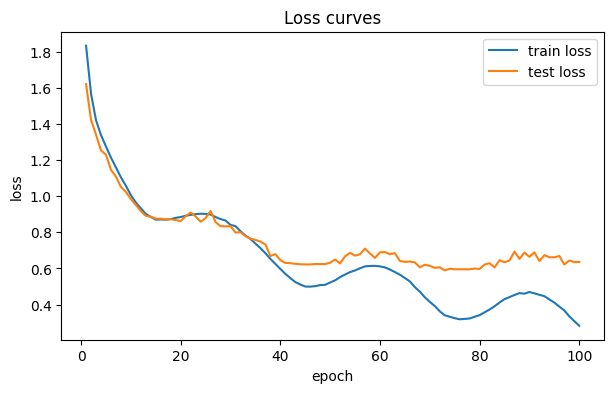

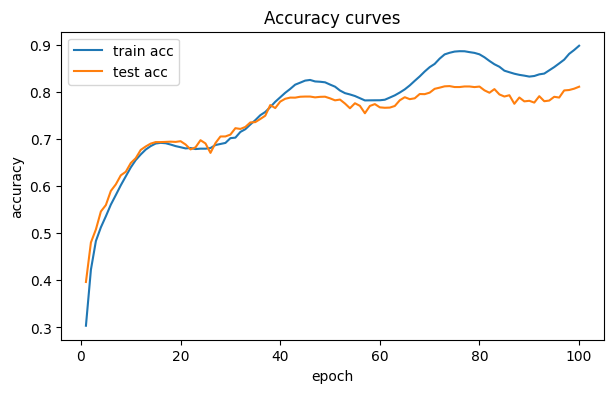

In [35]:
epochs_axis = list(range(1, len(history["train_loss"]) + 1))

plt.figure(figsize=(7, 4))
plt.plot(epochs_axis, history["train_loss"], label="train loss")
plt.plot(epochs_axis, history["test_loss"], label="test loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.title("Loss curves")
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(epochs_axis, history["train_acc"], label="train acc")
plt.plot(epochs_axis, history["test_acc"], label="test acc")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.legend()
plt.title("Accuracy curves")
plt.show()

## Show a few predictions

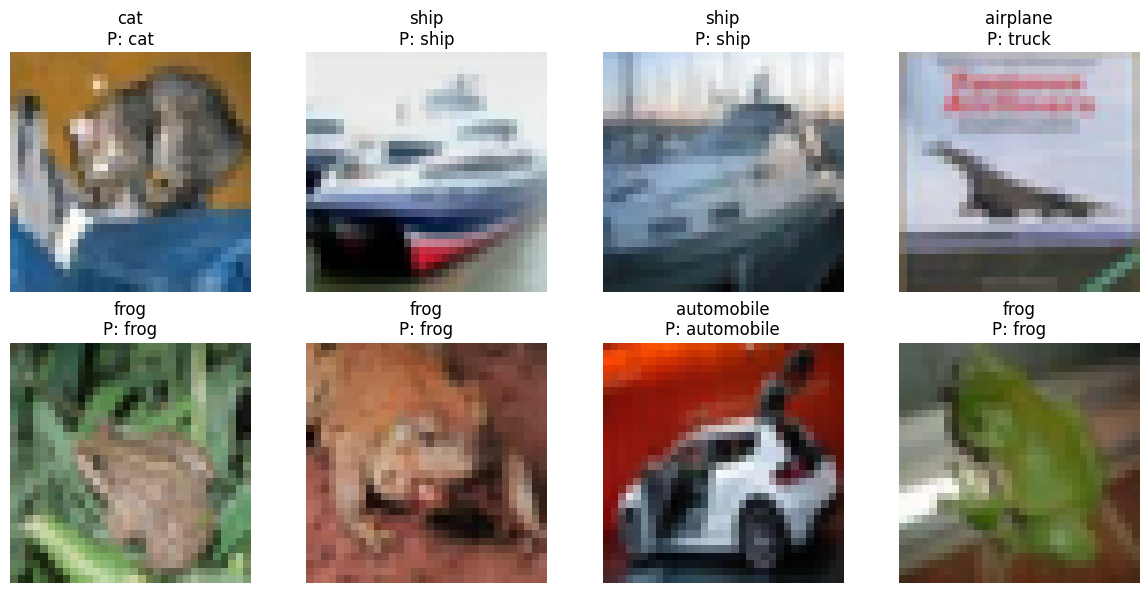

In [40]:
@torch.no_grad()
def show_predictions(model, loader, classes, device, num_images=8):
    model.eval()
    images, labels = next(iter(loader))
    images = images[:num_images].to(device)
    labels = labels[:num_images].to(device)

    logits = model(images)
    preds = logits.argmax(dim=1)

    cols = 4
    rows = (num_images + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(12, 3 * rows))
    axes = axes.flatten() if hasattr(axes, "flatten") else [axes]

    for ax, img, label, pred in zip(axes, images.cpu(), labels.cpu(), preds.cpu()):
        ax.imshow(denormalize(img).permute(1, 2, 0))
        ax.set_title(f"{classes[label.item()]}\nP: {classes[pred.item()]}")
        ax.axis("off")

    for ax in axes[num_images:]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

show_predictions(model, test_loader, classes, device, num_images=8)

## Summary

This example shows that the same ViT-style encoder can be used for **image classification** by adding a simple classification head.

The flow is:

$$
[B, 3, 32, 32]
\rightarrow
[B, 64, D]
\rightarrow
[B, 65, D]
\rightarrow
[B, D]
\rightarrow
[B, 10]
$$

where:

- $64$ comes from the $8 \times 8$ patch grid for `patch_size = 4`
- $65$ includes the extra class token
- the final output is one logit vector per image

This is also a useful bridge to **Vision-Language Models**:

- for classification, the image encoder feeds a classifier
- for CLIP/SigLIP, the image encoder feeds a projection head
- for LLaVA-like models, the image encoder feeds a projector into a language model

So the encoder itself remains central; only the **output head** changes.

## Comparing CNN vs ViT for classification and generation
It is interesting to compare CNN vs. ViT for classification and generation tasks.

### Classification: CNNs vs ViTs

This figure below  compares **ConvNets** and **Vision Transformers** on **ImageNet-1K classification**, with bubble size proportional to **FLOPs**. Once ConvNets were modernized with design choices inspired by Transformers, the CNN-based systems became competitive again. 

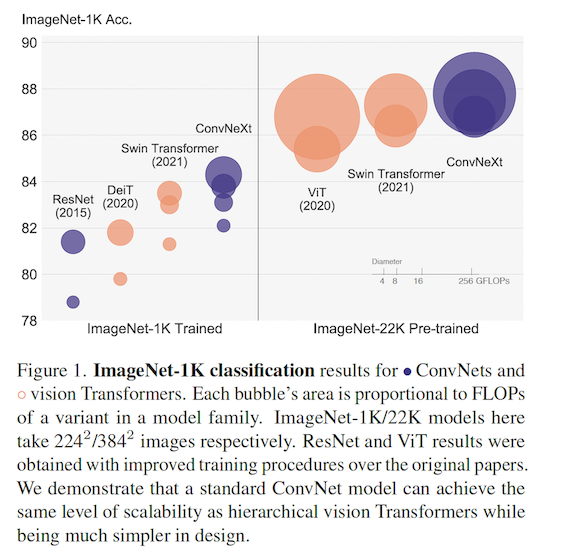

**ConvNeXt, Figure 1** from *A ConvNet for the 2020s*.

### Generative modeling: CNN-U-Net vs ViT backbone

#### Quality of Generation
We have used U-Net as the backbone for models like **Diffusion** and the questions is what happens if we replace **CNN-U-Net** with a **Vit-type** backbones. 

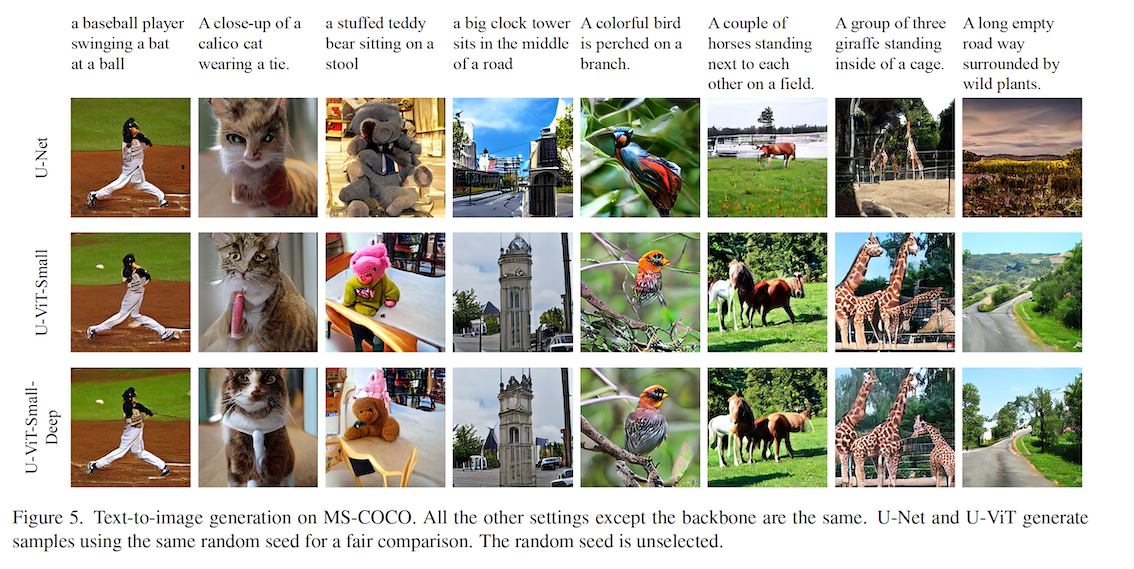

**U-ViT, Figure 5** from *All Are Worth Words: A ViT Backbone for Diffusion Models*.

This figure clearly shows that **U-Net** and **U-ViT** can generate similar samples using the same random seed for a fair comparison. So **U-ViT** is can deliver **visual quality** similar to **CNN-U_Nets**. 

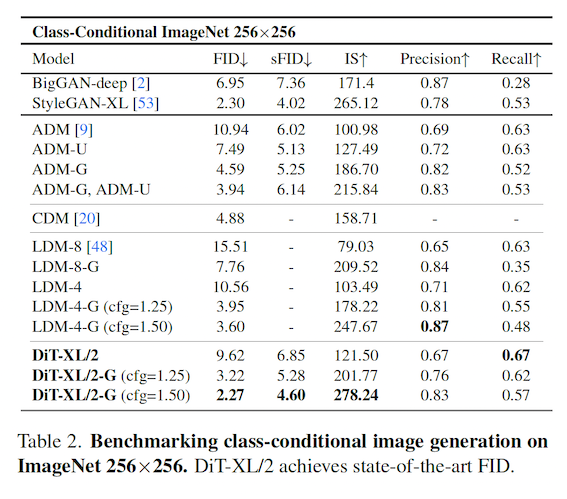

**U-ViT, Table 2** from *Scalable Diffusion Models with Transformers*

**Table 2** gives a direct numerical comparison on the  **MS-COCO 256 x 256** image dataset. 

- **U-Net\***: **FID 7.32**
- **U-ViT-S/2**: **FID 5.95**
- **U-ViT-S/2 (Deep)**: **FID 5.48**

Since **lower FID is better** which means that this is a clear quantitative sign that the **ViT-style** backbone is outperforming the **CNN-style U-Net** baseline in this setting.

- **FID ↓**: lower is better; a widely used measure of fidelity and distributional closeness to real images
- **sFID ↓**: lower is better; a spatial variant of FID that is often more sensitive to structure
- **IS ↑**: higher is better; rewards images that are individually recognizable and collectively varied across classes
- **Precision ↑**: higher is better; generated images stay close to the real-image manifold, so this is often interpreted as a **fidelity / realism** measure
- **Recall ↑**: higher is better; generated images cover more of the real data distribution, so this is often interpreted as a **diversity / coverage** measure

So in terms of pure sample quality, this table shows that:

1. **StyleGAN-XL** is the strongest overall model in this benchmark on the main fidelity metrics.
2. **DiT-XL/2-G (cfg = 1.50)** is extremely competitive and substantially better than earlier diffusion-style baselines.
3. **Guidance** matters a lot for DiT: the unguided **DiT-XL/2** has **FID = 12.03**, while guidance reduces this to **4.64** and then **3.04** as the guidance strength increases.

That last point is important: the transformer backbone is strong, but the final quality depends heavily on how effectively the model is guided at sampling time.

Note that here **Precision** and **Recall** is not what we expect in usual **classification tasks** but based on a special methodology (see https://arxiv.org/abs/1904.06991). We basically create many real and fake images and put **k-nearest neighbor** manifolds around them.  This type of **Precision** and **Recall** are especially helpful because they separate two ideas that FID mixes together.

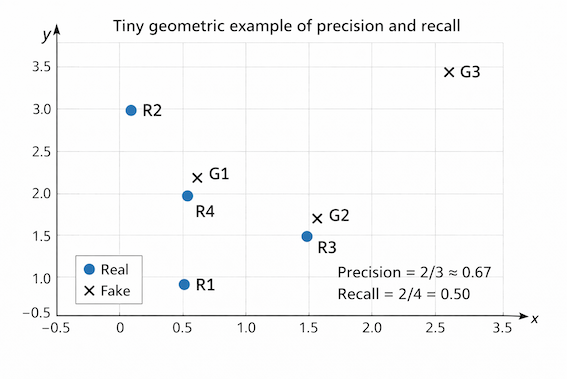

**Simple Example of Precision and Recall**
- **Precision** measures **realism** because it checks whether generated samples lie inside local **k-nearest-neighbor regions of real samples**.
- **Recall** measures **coverage** because it checks whether real samples lie inside local **k-nearest-neighbor regions of generated samples**.


- **ADM-G** has the best **Precision = 0.87**, which means its samples are especially concentrated in realistic regions of image space
- but its **Recall = 0.42** is not the best, meaning it does not cover the data distribution as broadly
- by contrast, **ADM-U** has lower precision (**0.75**) but much higher recall (**0.64**)

This is the clearest evidence in the table that **high realism does not automatically imply high diversity**.

#### Scaling 

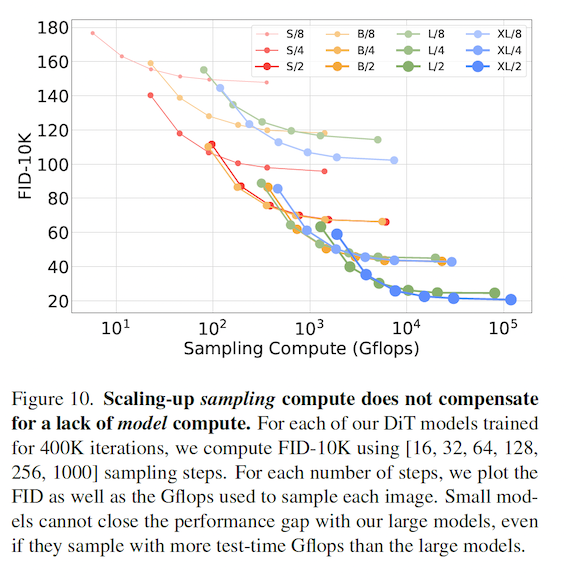

**U-ViT, Figure 10** from *Scalable Diffusion Models with Transformers*

Figure 10 above shows one of the primary strengths of transformer-based generative models showing that they **scale very effectively**.

The curves labeled **S, B, L, and XL** correspond to progressively larger DiT transformer models. The vertical axis shows **FID**, where lower is better, and the horizontal axis shows **sampling compute**, that is, how much computation is used at test time to generate an image.

The figure demonstrates the following important point. 

> **Larger transformer models achieve better results, and smaller models cannot catch up just by using more sampling compute.**

This is important because it shows that the improvement comes mainly from **scaling the model itself**, not just from spending more effort during sampling.

In other words:

- increasing the number of sampling steps helps
- but increasing the **size of the transformer** helps much more

This is one of the reasons transformers became so important in modern generative modeling. A major advantage of transformers is that their performance often improves in a **smooth and predictable way** as the model becomes larger.


### Summary

- In **classification**, CNNs and ViTs are both strong, and the best choice depends on the design and training setup.
- In **generation**, the field moved more clearly from **CNN-U-Net backbones** toward **ViT/DiT-style backbones** because transformers scaled better and handled global token interactions more naturally.

### References

1. Zhuang Liu, Hanzi Mao, Chao-Yuan Wu, Christoph Feichtenhofer, Trevor Darrell, and Saining Xie.  
   **A ConvNet for the 2020s.**  
   In *Proceedings of the IEEE/CVF Conference on Computer Vision and Pattern Recognition (CVPR)*, 2022.

2. Fan Bao, Shen Nie, Kaiwen Xue, Chongxuan Li, Song-Hai Zhang, and Ying-Cong Chen.  
   **All Are Worth Words: A ViT Backbone for Diffusion Models.**  
   In *Proceedings of the IEEE/CVF Conference on Computer Vision and Pattern Recognition (CVPR)*, 2023.

3. William Peebles and Saining Xie.  
   **Scalable Diffusion Models with Transformers.**  
   arXiv:2212.09748, 2022.

## Use of Generative AI

Portions of this material were developed with the assistance of **generative artificial intelligence tools.  
The author reviewed, edited, and validated all content, including explanations, code, and examples, and assumes full responsibility for accuracy and interpretation.